## 4.10 Uso de modelo LLM en zero-shot

Los modelos de lenguaje de gran tamaño (LLM) permiten realizar tareas de clasificación sin entrenamiento específico mediante técnicas zero-shot.

Ventajas:
- No requieren datos etiquetados
- Fácil implementación

Limitaciones:
- Mayor coste computacional
- Menor control sobre el comportamiento
- Variabilidad en los resultados

## 5. Modelo avanzado o LLM — 15%

Se valorará la inclusión de un enfoque avanzado usando un LLM mediante prompting.

Aspectos esperados si se usa LLM:

- Prompt claro y controlado.
- Salida estructurada.
- Evaluación sobre una muestra representativa.
- Comparación con los modelos entrenados.
- Discusión sobre coste, latencia, privacidad, reproducibilidad y robustez.

Máxima puntuación si el modelo avanzado no se presenta como “magia”, sino como otra herramienta con ventajas y limitaciones.

In [ ]:
# ERROR

Error en fila 40: headers: {'access-control-expose-headers': 'X-Debug-Trace-ID', 'cache-control': 'no-cache, no-store, no-transform, must-revalidate, private, max-age=0', 'content-encoding': 'gzip', 'content-type': 'application/json', 'expires': 'Thu, 01 Jan 1970 00:00:00 GMT', 'pragma': 'no-cache', 'vary': 'Origin,Accept-Encoding', 'x-accel-expires': '0', 'x-debug-trace-id': 'e81ee10a682206442fdf359f50adc547', 'date': 'Tue, 12 May 2026 11:11:05 GMT', 'x-envoy-upstream-service-time': '3', 'server': 'envoy', 'via': '1.1 google', 'alt-svc': 'h3=":443"; ma=2592000,h3-29=":443"; ma=2592000', 'transfer-encoding': 'chunked'}, status_code: 429, body: {'id': 'd325bff4-5f9f-46f8-89c6-7f1b7a454598', 'message': "You are using a Trial key, which is limited to 40 API calls / minute. You can continue to use the Trial key for free or upgrade to a Production key with higher rate limits at 'https://dashboard.cohere.com/api-keys'. Contact us on 'https://discord.gg/XW44jPfYJu' or email us at support@cohe

KeyboardInterrupt: 

The HTTP 429 error is a 'Rate Limit' warning. It means our script is talking to the server too fast. Since we are using a free Trial Key, Cohere limits us to 40 requests per minute. To fix this, we must teach our code to 'slow down' using delays or to wait and retry when the server says it's busy.

There is a second restriction called Usage Quota. While the first error was about 'speed' (Rate Limit), this one is about 'volume'. We had a monthly allowance of 1,000 requests, we spent our entire monthly budget in just 2 hours.

In [ ]:
# test

import pandas as pd
import cohere
import time
import os

clave = os.environ.get("COHERE_API_KEY")
co = cohere.ClientV2(clave)
system_prompt = (
    "Actúa como un clasificador de sentimientos binario. "
    "Analiza el texto del usuario y responde ÚNICAMENTE con la palabra 'positive' o 'negative'. "
    "No añadas puntos, ni explicaciones, ni mayúsculas.\n\n"
    "Ejemplos de clasificación:\n"
    "Texto: for some reason I read CARA PWN . ) but thank you .\n"
    "Respuesta: positive\n\n"
    "Texto: very glad that u are feeling better ! I could n't sleep in more\n"
    "Respuesta: negative\n\n"
    "Texto: Stayed up last night working . Now , I am going back to bed\n"
    "Respuesta: positive\n\n"
    "Texto: Going to bed . Its been an awful day .\n"
    "Respuesta: negative"
)

texto = "I miss all of my camp friend more than I could ever imagine"

response = co.chat(
    model="command-a-03-2025",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": texto}
    ],
    temperature=0.0 # Crítico: reduce a 0 para maximizar la reproducibilidad
)

print(response.message.content[0].text)
        
# Rate limiting: pausa de 0.5s para no saturar la API en el tier gratuito
time.sleep(0.5)

negative


In [ ]:
import pandas as pd
import cohere
import time
import os

# 1. Configuración
co = cohere.ClientV2("cohere_lJ6zElz1pfMnlPa3Q0vXIEv7On7IkL3qzhn489LH4Ud1Tz")

archivo_entrada = "test_preprocessed.csv"
archivo_salida = "predicciones_30min.csv"

# 2. Carga y Submuestreo Estratégico (1125 filas = ~30 minutos)
if os.path.exists(archivo_salida):
    df = pd.read_csv(archivo_salida)
    filas_hechas = len(df[df['pred_llm'].notna() & (df['pred_llm'] != 'error')])
    print(f"[INFO] Retomando ejecución: {filas_hechas} filas ya procesadas.")
else:
    df_completo = pd.read_csv(archivo_entrada)
    # Seleccionamos exactamente 1125 filas de forma aleatoria para evitar sesgos
    df = df_completo.sample(n=1125, random_state=42).reset_index(drop=True)
    df['pred_llm'] = None 

# 3. Prompting (Few-Shot)
system_prompt = (
    "Actúa como un clasificador de sentimientos binario. "
    "Analiza el texto del usuario y responde ÚNICAMENTE con la palabra 'positive' o 'negative'. "
    "No añadas puntos, ni explicaciones, ni mayúsculas.\n\n"
    "Ejemplos:\n"
    "Texto: for some reason I read CARA PWN . ) but thank you .\n"
    "Respuesta: positive\n\n"
    "Texto: very glad that u are feeling better ! I could n't sleep in more\n"
    "Respuesta: negative\n\n"
    "Texto: Stayed up last night working . Now , I am going back to bed\n"
    "Respuesta: positive\n\n"
    "Texto: Going to bed . Its been an awful day .\n"
    "Respuesta: negative"
)

# 4. Parámetros de Seguridad
frecuencia_guardado = 50 
pausa_normal = 1.6  
pausa_bloqueo = 60  

# 5. Iteración
for index, row in df.iterrows():
    if pd.notna(row['pred_llm']) and row['pred_llm'] != "error":
        continue
        
    texto = str(row['text'])
    
    try:
        response = co.chat(
            model="command-a-03-2025",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": texto}
            ],
            temperature=0.0
        )
        
        df.at[index, 'pred_llm'] = response.message.content[0].text.strip().lower()
        
    except Exception as e:
        error_msg = str(e)
        print(f"[ERROR] Fila {index}: {error_msg}")
        
        if "429" in error_msg:
            df.at[index, 'pred_llm'] = "error" 
            time.sleep(pausa_bloqueo) 
        else:
            df.at[index, 'pred_llm'] = "error"
            time.sleep(2)
        
    time.sleep(pausa_normal)
    
    if (index + 1) % frecuencia_guardado == 0:
        df.to_csv(archivo_salida, index=False)
        print(f"[GUARDADO] Checkpoint: Fila {index + 1} alcanzada.")

# 6. Cierre
df.to_csv(archivo_salida, index=False)
print("[ÉXITO] 30 minutos de procesamiento completados. Archivo final generado.")

[GUARDADO] Checkpoint: Fila 50 alcanzada.
[GUARDADO] Checkpoint: Fila 100 alcanzada.
[GUARDADO] Checkpoint: Fila 150 alcanzada.
[GUARDADO] Checkpoint: Fila 200 alcanzada.
[GUARDADO] Checkpoint: Fila 250 alcanzada.
[GUARDADO] Checkpoint: Fila 300 alcanzada.
[GUARDADO] Checkpoint: Fila 350 alcanzada.
[GUARDADO] Checkpoint: Fila 400 alcanzada.
[GUARDADO] Checkpoint: Fila 450 alcanzada.
[GUARDADO] Checkpoint: Fila 500 alcanzada.
[GUARDADO] Checkpoint: Fila 550 alcanzada.
[GUARDADO] Checkpoint: Fila 600 alcanzada.
[GUARDADO] Checkpoint: Fila 650 alcanzada.
[GUARDADO] Checkpoint: Fila 700 alcanzada.
[GUARDADO] Checkpoint: Fila 750 alcanzada.


Total filas válidas evaluadas: 750

--- ACCURACY (Exactitud) ---
0.8040

--- CLASSIFICATION REPORT (Precision, Recall, F1) ---
              precision    recall  f1-score   support

    negative       0.85      0.79      0.82       420
    positive       0.76      0.82      0.79       330

    accuracy                           0.80       750
   macro avg       0.80      0.81      0.80       750
weighted avg       0.81      0.80      0.80       750



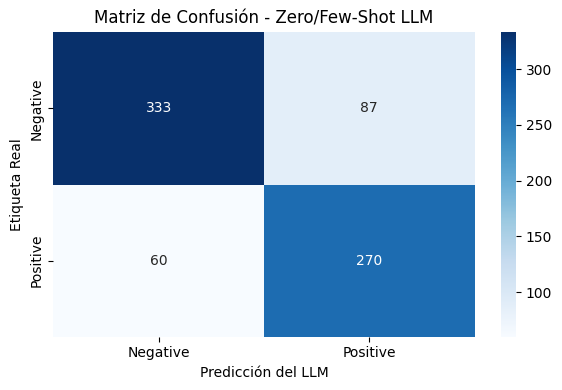

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar las predicciones
df = pd.read_csv("predicciones_30min.csv")

# 2. Limpieza de seguridad
# Filtramos filas donde haya fallado la API ('error') o haya nulos
df_clean = df.dropna(subset=['label', 'pred_llm'])
df_clean = df_clean[df_clean['pred_llm'] != 'error']

# Estandarizamos texto (minúsculas y sin espacios extra) por si acaso
y_true = df_clean['label'].str.lower().str.strip()
y_pred = df_clean['pred_llm'].str.lower().str.strip()

# 3. Cálculo de Métricas
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=['negative', 'positive'])

# 4. Mostrar Resultados Numéricos
print(f"Total filas válidas evaluadas: {len(df_clean)}")
print(f"\n--- ACCURACY (Exactitud) ---")
print(f"{accuracy:.4f}")
print(f"\n--- CLASSIFICATION REPORT (Precision, Recall, F1) ---")
print(report)

# 5. Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicción del LLM')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - Zero/Few-Shot LLM')
plt.tight_layout()

# Muestra el gráfico en el notebook
plt.show()

Aunque el LLM ha obtenido las mejores métricas puras, concluir que es el mejor modelo es un error analítico. El mejor modelo no es el que más acierta, sino el que resuelve el problema de la forma más eficiente según los recursos disponibles.


LLMs (El experto en contexto): Su ventaja innegable es que entienden el lenguaje. Al trabajar con datos de redes sociales, el LLM es capaz de captar la ironía, la jerga y el contexto implícito; algo para lo que un enfoque puramente matemático (TF-IDF) es ciego. Es una opción ideal si tienes pocos datos etiquetados, y dispones del presupuesto y tiempo para pagar y esperar por cada llamada a la API.


Modelos Clásicos con TF-IDF (El motor industrial): Si el escenario cambia y tienes datos masivos pero recursos económicos y de infraestructura limitados, TF-IDF es imbatible. Sacrifica la comprensión profunda del texto, pero lo compensa con escalabilidad total, respuestas en milisegundos y un coste de inferencia igual a cero.


Redes LSTM (El punto intermedio): Se sitúan exactamente en el centro, asumiendo lo mejor y lo peor de los dos mundos anteriores. Logran capturar el contexto y la secuencia de las palabras (superando a TF-IDF) sin obligarte a depender financieramente de una API externa de pago. Sin embargo, su limitación es que requieren una gran cantidad de datos y potencia de cómputo (GPU) para entrenarse desde cero.

El veredicto: Como analista de datos, tu decisión técnica debe ser estratégica. Usa el LLM para calidad y prototipado rápido, usa TF-IDF para volumen masivo a bajo coste, y usa LSTM cuando necesites un equilibrio propietario entre ambas fuerzas.
